In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
folder = "/eos/user/m/mmarcheg/ml4reco/data/taus_2025/npz"
#folder = "/afs/cern.ch/user/j/jgaytanv/public"
os.listdir(folder)

['step3_Tau_E200_n1000_part1_000_neg.npz',
 'step3_Tau_E200_n1000_part1_000_pos.npz',
 'step3_Tau_E200_n1000_part1_001_neg.npz',
 'step3_Tau_E200_n1000_part1_001_pos.npz',
 'step3_Tau_E200_n1000_part1_002_neg.npz',
 'step3_Tau_E200_n1000_part1_002_pos.npz',
 'step3_Tau_E200_n1000_part1_003_neg.npz',
 'step3_Tau_E200_n1000_part1_003_pos.npz',
 'step3_Tau_E200_n1000_part1_004_neg.npz',
 'step3_Tau_E200_n1000_part1_004_pos.npz',
 'step3_Tau_E200_n1000_part1_005_neg.npz',
 'step3_Tau_E200_n1000_part1_005_pos.npz',
 'step3_Tau_E200_n1000_part1_006_neg.npz',
 'step3_Tau_E200_n1000_part1_006_pos.npz',
 'step3_Tau_E200_n1000_part1_007_neg.npz',
 'step3_Tau_E200_n1000_part1_007_pos.npz',
 'step3_Tau_E200_n1000_part1_008_neg.npz',
 'step3_Tau_E200_n1000_part1_008_pos.npz',
 'step3_Tau_E200_n1000_part1_009_neg.npz',
 'step3_Tau_E200_n1000_part1_009_pos.npz',
 'step3_Tau_E200_n1000_part1_010_neg.npz',
 'step3_Tau_E200_n1000_part1_010_pos.npz',
 'step3_Tau_E200_n1000_part1_011_neg.npz',
 'step3_Tau

In [3]:
filename = os.path.join(folder, "step3_Tau_E200_n1000_part2_238_neg.npz")
#filename = os.path.join(folder, "step3_Tau_E200_n1000_part9_999_pos_NOFINE.npz")
#filename = os.path.join(folder, "step3_Tau_E200_n1000_part9_299_neg_NOFINE.npz")
a = np.load(filename, allow_pickle=True)
a

NpzFile '/eos/user/m/mmarcheg/ml4reco/data/taus_2025/npz/step3_Tau_E200_n1000_part2_238_neg.npz' with keys: metadata, rechits_keys, rechits_array, simtracks_keys, simtracks_array...

In [4]:
a.files

['metadata',
 'rechits_keys',
 'rechits_array',
 'simtracks_keys',
 'simtracks_array',
 'simclusters_keys',
 'simclusters_array']

In [5]:
a["rechits_keys"]

array(['RecHitHGC_x', 'RecHitHGC_y', 'RecHitHGC_z', 'RecHitHGC_energy',
       'RecHitHGC_time', 'RecHitHGC_MergedSimClusterBestMatchIdx',
       'RecHitHGC_MergedSimClusterBestMatchQual', 'RecHitHGC_theta',
       'RecHitHGC_eta', 'RecHitHGC_phi', 'RecHitHGC_R',
       'RecHitHGC_incrClusterIdx'], dtype='<U39')

In [6]:
df = pd.DataFrame(a["rechits_array"], columns=a["rechits_keys"])
df

,RecHitHGC_x,RecHitHGC_y,RecHitHGC_z,RecHitHGC_energy,RecHitHGC_time,RecHitHGC_MergedSimClusterBestMatchIdx,RecHitHGC_MergedSimClusterBestMatchQual,RecHitHGC_theta,RecHitHGC_eta,RecHitHGC_phi,RecHitHGC_R,RecHitHGC_incrClusterIdx
0,37.929375,-4.433446,322.154999,0.004073,-99.0,-1.0,0.0,0.117987,2.829164,1.687155,324.410444,0.0
1,56.777714,-28.212837,354.368988,0.006675,-99.0,-1.0,0.0,0.177039,2.421916,2.031961,359.995906,0.0
2,45.608330,-34.661484,354.368988,0.005840,-99.0,-1.0,0.0,0.160266,2.521922,2.220655,358.969244,0.0
3,51.193024,-25.794594,354.368988,0.005840,-99.0,-1.0,0.0,0.160375,2.521238,2.037535,358.975579,0.0
4,42.815983,-30.631081,354.368988,0.006675,-99.0,-1.0,0.0,0.147481,2.605391,2.191791,358.258079,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
20968,-44.444851,38.288849,326.205994,0.037285,-99.0,32.0,1.0,0.177933,2.416851,-0.859669,331.438880,16.0
20969,-45.841026,41.513176,326.205994,0.007035,-99.0,32.0,1.0,0.187364,2.364920,-0.834901,332.016707,16.0
20970,-45.841026,44.737499,326.205994,0.017588,-99.0,32.0,1.0,0.193892,2.330461,-0.797581,332.435248,16.0
20971,-50.029545,41.513176,350.987000,0.050060,-99.0,32.0,1.0,0.183145,2.387824,-0.878163,356.956822,16.0


In [7]:
def plot_variables(df, variables):
    """
    Plots any number of RecHitHGC variables from a DataFrame in 2-column subplots.
    
    Parameters:
    - df: pandas DataFrame with RecHitHGC variables.
    - variables: list of variable names (strings) to plot.
    """
    n_vars = len(variables)
    n_cols = 2
    n_rows = (n_vars + 1) // 2  # round up division

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()

    for i, var in enumerate(variables):
        data = df[var].values
        ax = axes[i]
        ax.hist(data, bins=50, color='steelblue', alpha=0.7)
        ax.set_title(var)
        ax.set_xlabel(var)
        ax.set_ylabel('Counts')
        ax.grid(True)

    # Turn off any unused subplots
    for j in range(len(variables), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [8]:
x = df.RecHitHGC_x.values
y = df.RecHitHGC_y.values
z = df.RecHitHGC_z.values
E = df.RecHitHGC_energy.values
t = df.RecHitHGC_time.values
theta = df.RecHitHGC_theta.values
eta = df.RecHitHGC_eta.values
phi = df.RecHitHGC_phi.values
R = df.RecHitHGC_R.values

In [9]:
any(phi == -1)

False

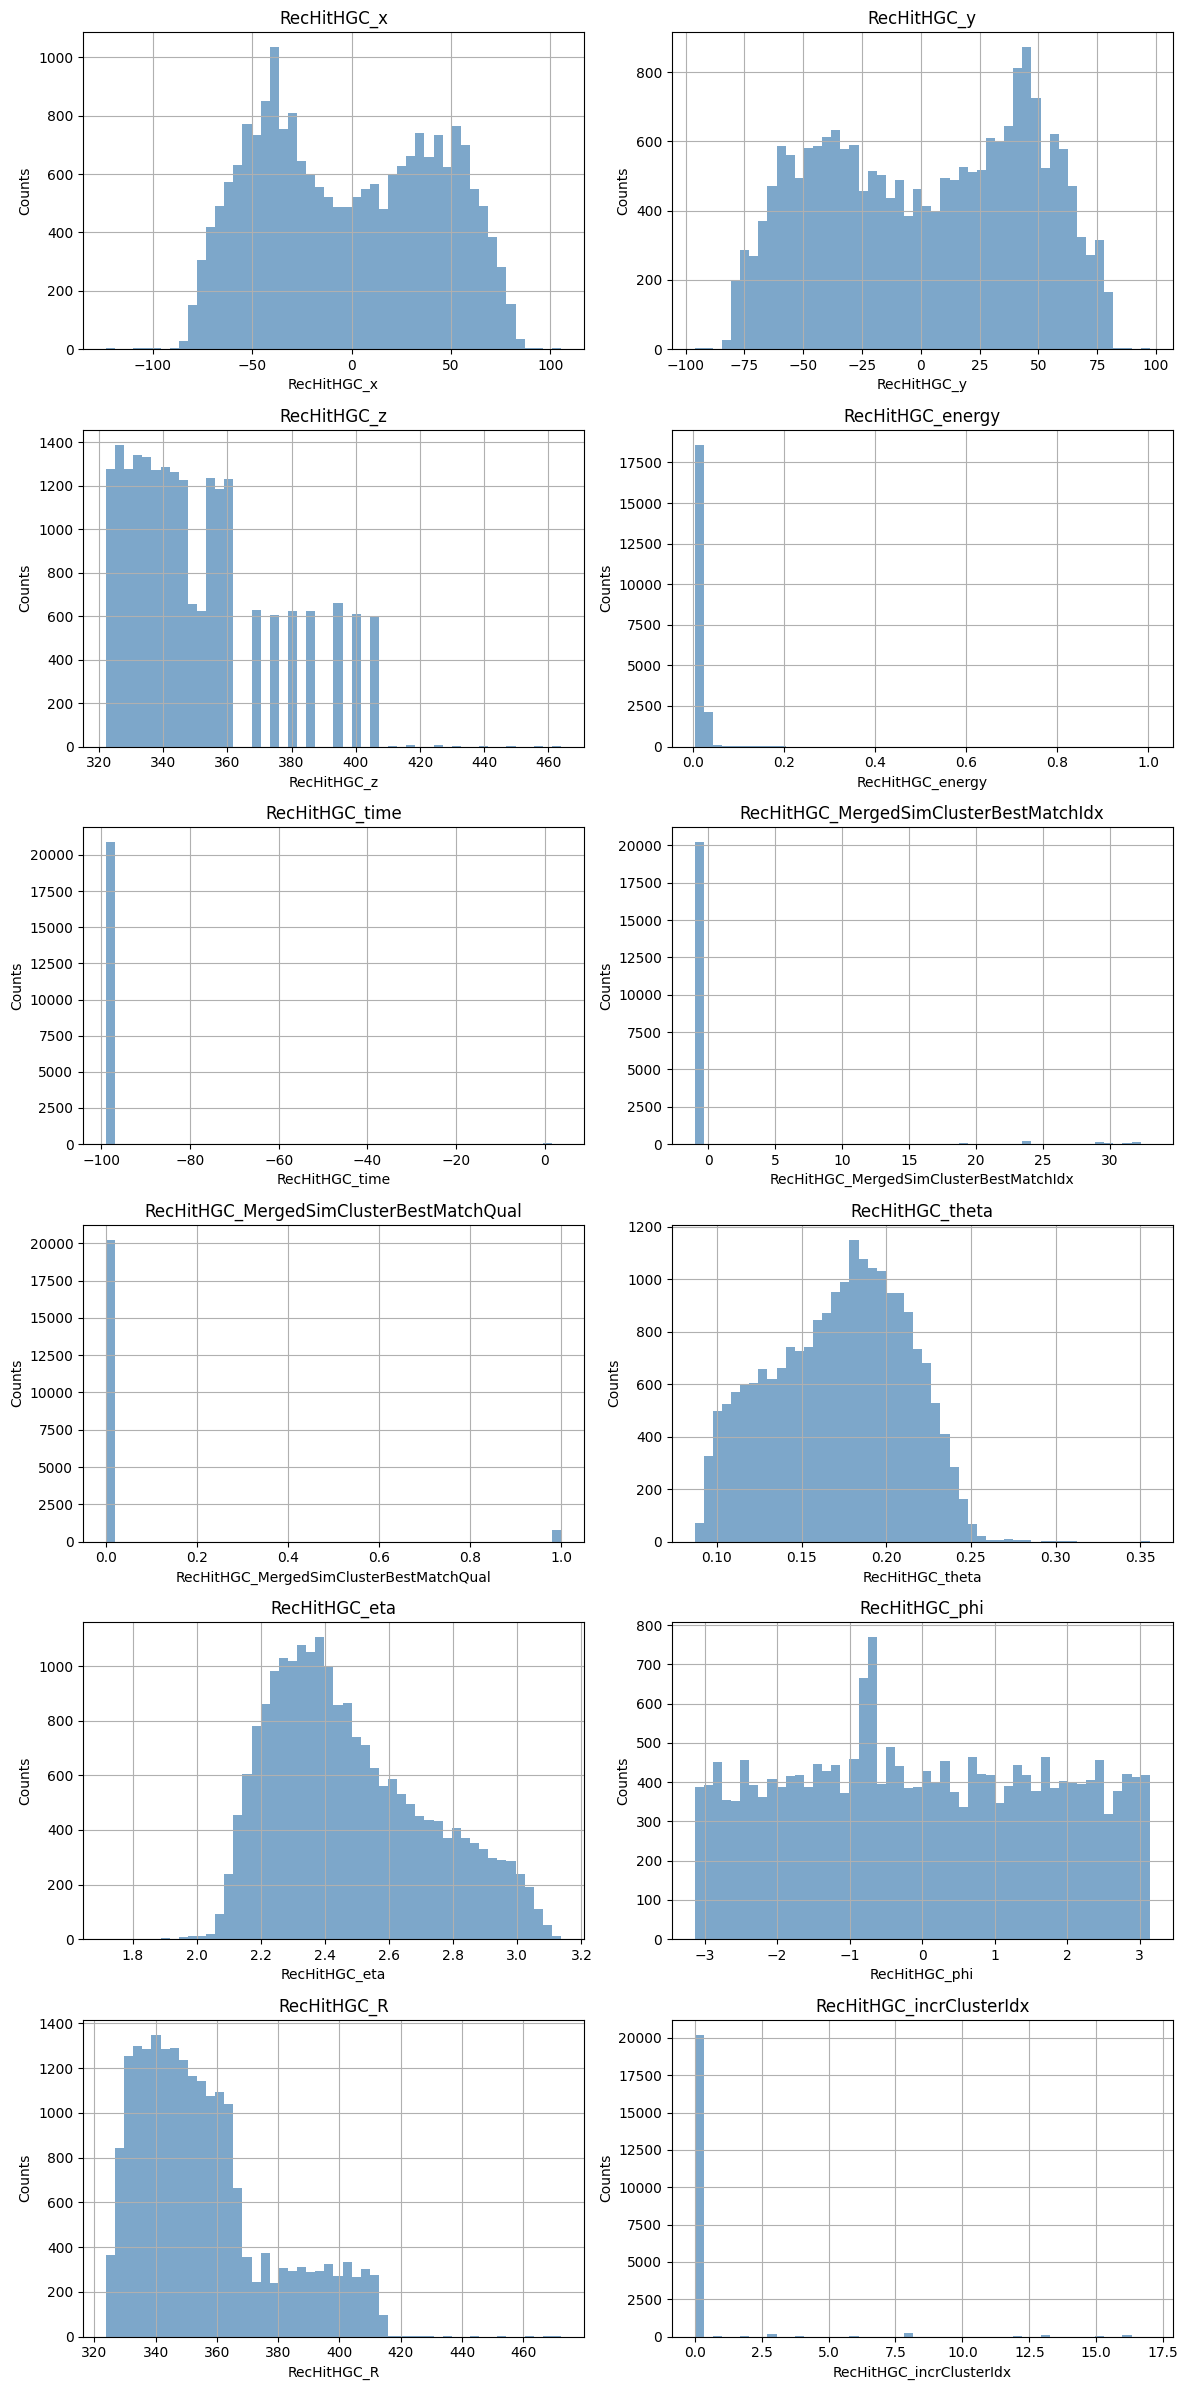

In [10]:
plot_variables(df, variables=df.columns)

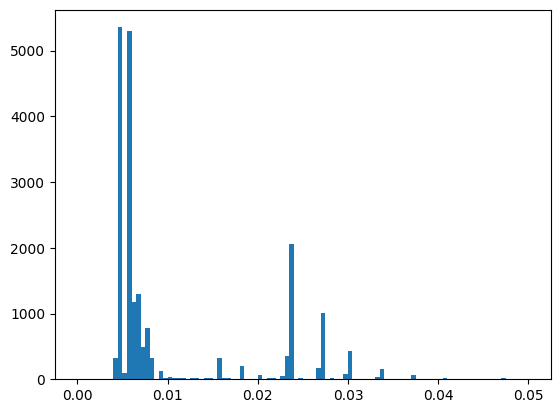

In [11]:
plt.hist(E, bins=100, range=(0,0.05));

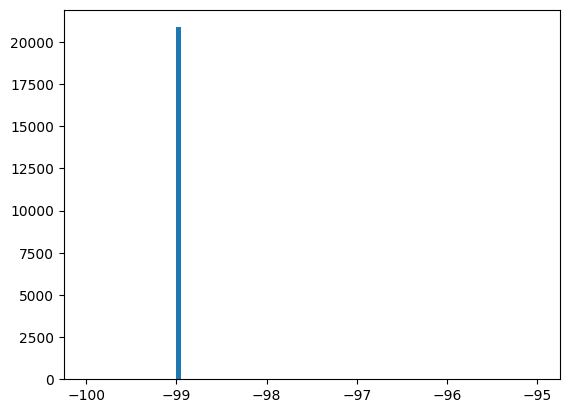

In [12]:
plt.hist(t, bins=100, range=(-100,-95));

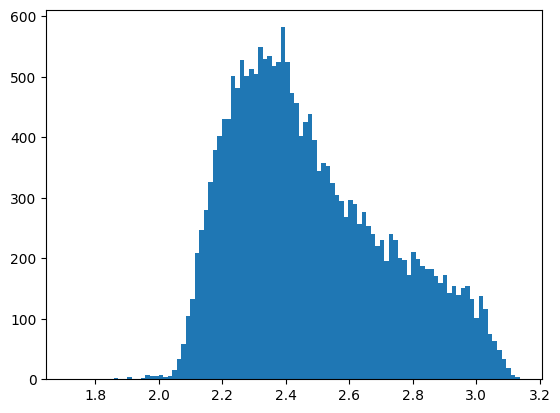

In [13]:
plt.hist(eta, bins=100);

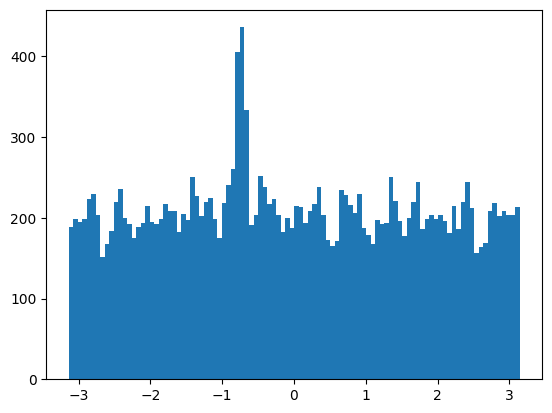

In [14]:
plt.hist(phi, bins=100);

In [15]:
df_simclusters = pd.DataFrame(a["simclusters_array"], columns=a["simclusters_keys"])
df_simclusters

,MergedSimCluster_impactPoint_eta,MergedSimCluster_impactPoint_phi,MergedSimCluster_impactPoint_x,MergedSimCluster_impactPoint_y,MergedSimCluster_impactPoint_z,MergedSimCluster_boundaryEnergy,MergedSimCluster_recEnergy,MergedSimCluster_pdgId,MergedSimCluster_trackIdAtBoundary
0,3.260864,1.835754,-5.904785,21.759766,293.5,0.355743,0.297582,-11.0,208527.0
1,2.196655,1.286682,18.523438,63.429688,293.5,0.113834,0.059232,22.0,208542.0
2,2.337402,2.029541,-25.340820,51.310547,293.5,3.779175,4.327375,22.0,208524.0
3,2.584717,2.677002,-39.800781,19.949219,293.5,0.556427,0.761581,11.0,216794.0
4,2.404785,2.575928,-45.113281,28.639648,293.5,0.038349,0.070731,22.0,229724.0
5,2.879517,2.133667,-17.648438,27.967773,293.5,0.183990,0.056745,-11.0,216793.0
6,2.641846,1.683716,-4.734375,41.755859,293.5,0.216202,0.179354,22.0,230669.0
7,2.396729,2.323853,-36.839844,39.304688,293.5,14.153809,13.409975,0.0,216795.0
8,2.677734,2.385254,-29.480469,27.812500,293.5,0.125763,0.009891,-11.0,247523.0
9,2.504272,2.406982,-35.845703,32.378906,293.5,0.773865,0.545003,11.0,247522.0


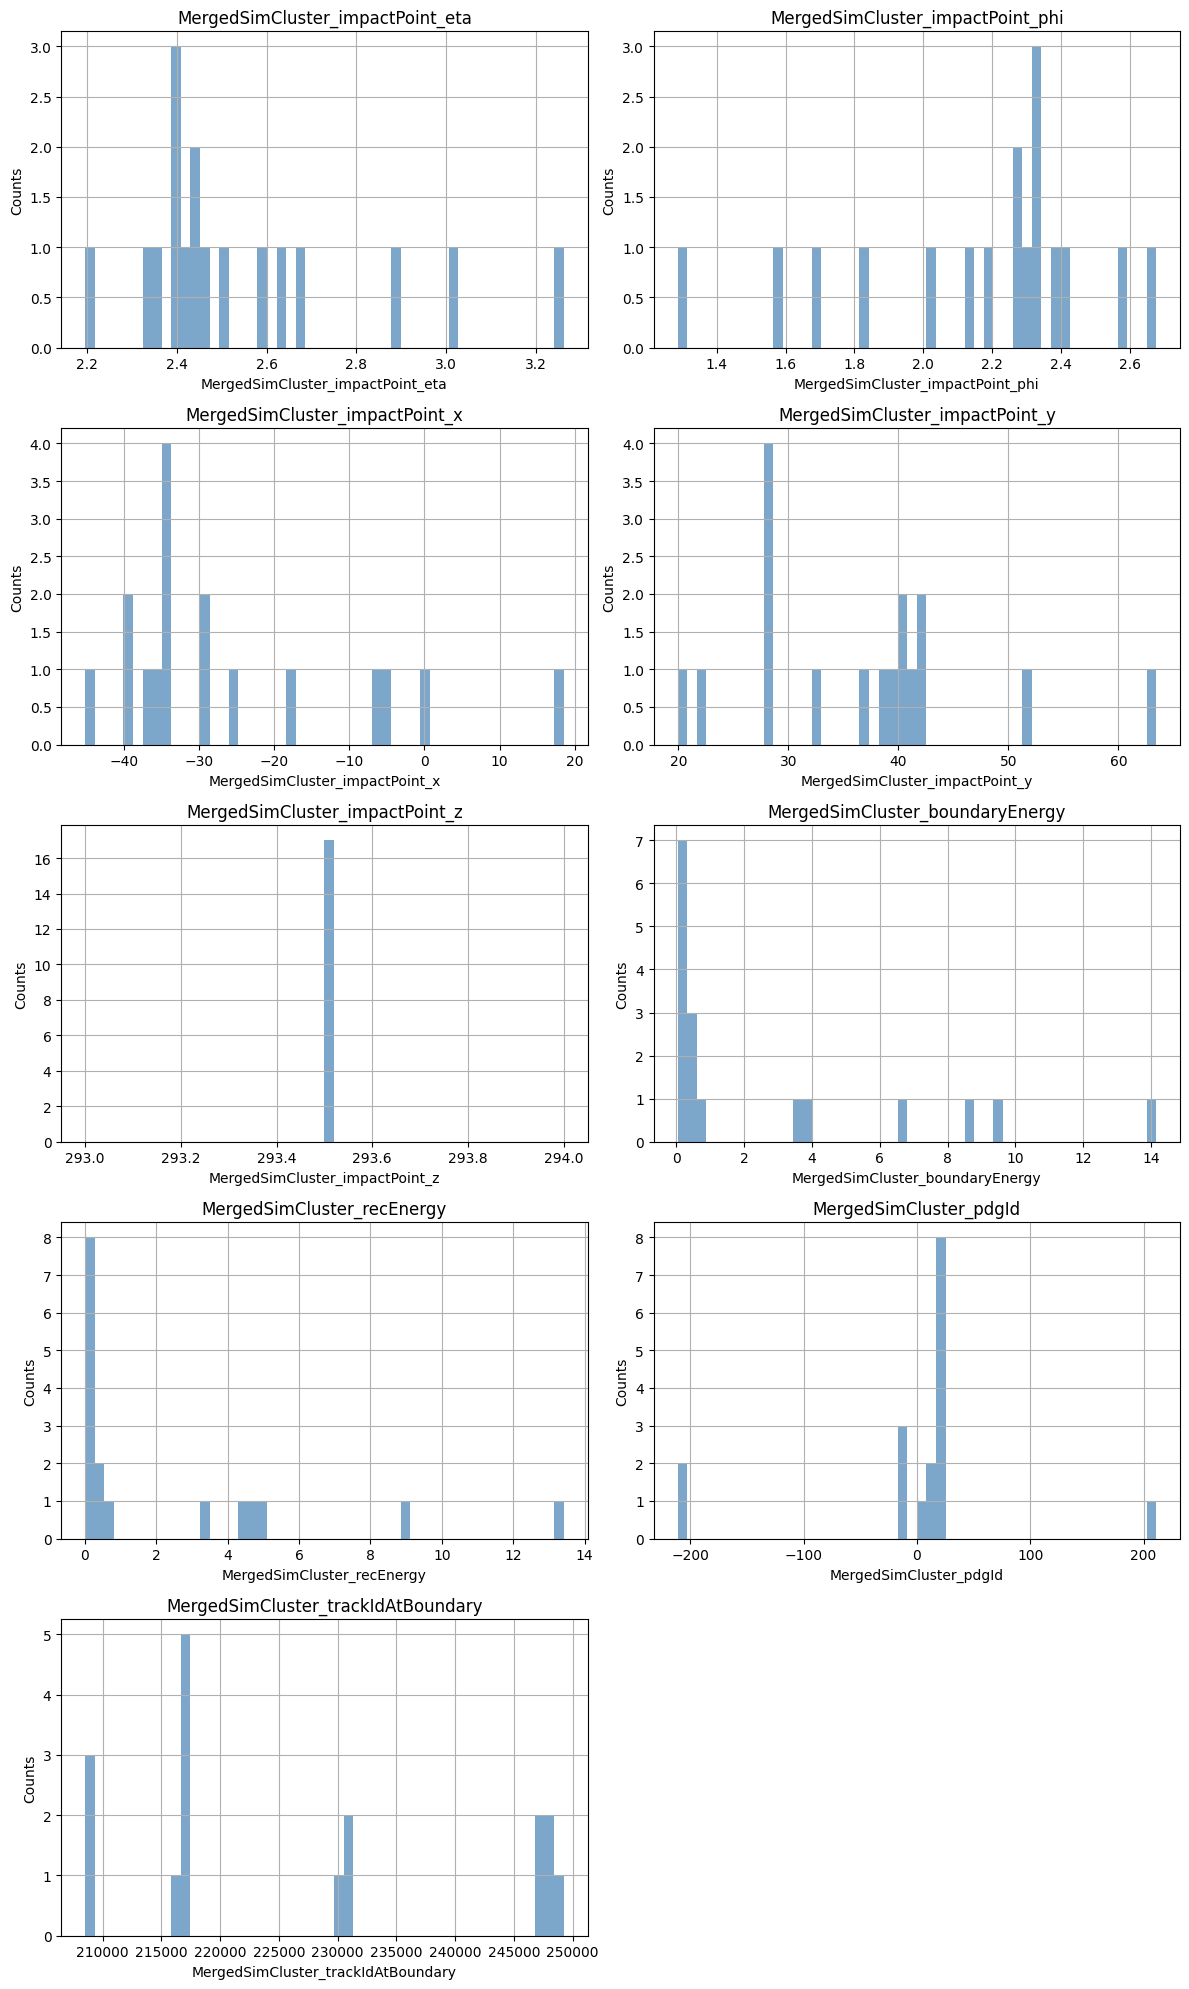

In [16]:
plot_variables(df_simclusters, df_simclusters.columns)

In [17]:
len(a["simtracks_array"])

33

# Plot energy of noise clusters

In [18]:
import mplhep as hep
hep.style.use("CMS")

In [19]:
energy_noise = df[df['RecHitHGC_incrClusterIdx'] == 0]['RecHitHGC_energy'].values
energy_signal = df[df['RecHitHGC_incrClusterIdx'] != 0]['RecHitHGC_energy'].values
energy_noise

array([0.0040729 , 0.00667477, 0.0058403 , ..., 0.00562811, 0.00633144,
       0.00492454])

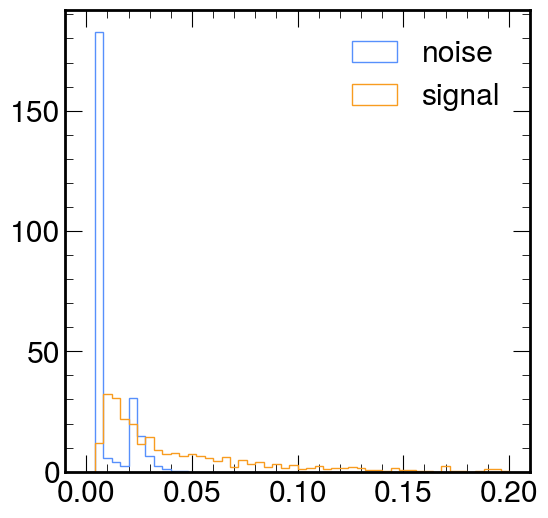

In [31]:
fig, ax = plt.subplots(1,1,figsize=[6,6])
plt.hist(energy_noise, bins=50, range=(0,0.2), label="noise", density=True, histtype="step")
plt.hist(energy_signal, bins=50, range=(0,0.2), label="signal", density=True, histtype="step")
plt.legend();

In [28]:
energy_noise.mean()

0.010496192537120903

In [29]:
energy_signal.mean()

0.05459837882549732

In [30]:
energy_noise[energy_noise < 0.02].mean()

0.006109206901349201